# EDA

[Jacob Phillips] Which properties best meet the client’s requirements for a large, historic estate with 4+ bathrooms
(or a smaller nearby alternative), featuring luxury amenities (tennis court and pool), proximity to golf, and explicitly 
excluding waterfront locations?

H1: "If a property is in a “golf community” zip code, then it will show 
higher average price per square foot than properties outside
those areas."

H2: "The higher the average neighbor lot size, the more likely the property itself
has a large estate-style lot, aligning with the client’s outdoor amenity needs."

H3: If a a property is historic, then it is more likely to be situated on larger lots.





In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib.ticker import PercentFormatter
plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
plt.rcParams["figure.facecolor"]= "w"
pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
# Load the exported CSV
df = pd.read_csv(".data\king_county_houses_joined.csv")

# Quick check
print(df.head())
print(df.info())

     house_id  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  7129300520     3.000      1.000     1180.000  5650.000   1.000         NaN   
1  6414100192     3.000      2.250     2570.000  7242.000   2.000       0.000   
2  5631500400     2.000      1.000      770.000 10000.000   1.000       0.000   
3  2487200875     4.000      3.000     1960.000  5000.000   1.000       0.000   
4  1954400510     3.000      2.000     1680.000  8080.000   1.000       0.000   

   view  condition  grade  ...  sqft_basement  yr_built  yr_renovated  \
0 0.000          3      7  ...          0.000      1955         0.000   
1 0.000          3      7  ...        400.000      1951     19910.000   
2 0.000          3      6  ...          0.000      1933           NaN   
3 0.000          5      7  ...        910.000      1965         0.000   
4 0.000          3      8  ...          0.000      1987         0.000   

   zipcode    lat     long  sqft_living15  sqft_lot15   sale_date sale_pri

In [4]:
#count the number of rows and columns
print(df.shape)

(21597, 21)


In [5]:
#check how many duplicated rows exist
df.duplicated().value_counts()

False    21597
Name: count, dtype: int64

In [6]:
df.dtypes

house_id           int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
sale_date         object
sale_price       float64
dtype: object

**Cleaning Data**

In [7]:
#fixing data types
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['zipcode'] = df['zipcode'].astype(str)

# check
df.dtypes


# Make columns lowercase, replace spaces with underscores, remove quotes.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace('"', '')
)

In [8]:
#check missing values
print(df.isnull().sum())

house_id            0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
sale_date           0
sale_price          0
dtype: int64


In [9]:
# Fill yr_renovated missing values with 0 (since many houses aren’t renovated).
df['yr_renovated'] = df['yr_renovated'].fillna(0)
# Fill view and condition missing values with median and mode respectively.
df['view'] = df['view'].fillna(df['view'].median())
df['condition'] = df['condition'].fillna(df['condition'].mode()[0])

In [10]:
#save cleaned data
df.to_csv(".data/king_county_houses_cleaned.csv", index=False)


# Hypothesis 1
"If a property is in a “golf community” zip code, then it will show 
higher average price per square foot than properties outside
those areas."

In [11]:
#H1:If a property is in a “golf community” zip code, then it will show higher average price per square foot than properties outside those areas.

#STEP 1: List of zip codes considered to be "golf communities" in King County, WA
golf_zipcodes = [
    "98005", "98008", "98022", "98024", "98028", "98032", "98038", "98042",
    "98045", "98052", "98053", "98058", "98059", "98065", "98074", "98092",
    "98103", "98108", "98112", "98115", "98119", "98125", "98126", "98168",
    "98177"
]

In [12]:
df = pd.read_csv(".data/king_county_houses_cleaned.csv")

# ensure zipcode is string for comparison
df['zipcode'] = df['zipcode'].astype(str).str.strip()

In [13]:
#Filter properties in those ZIPs
df_golf = df[df['zipcode'].isin(golf_zipcodes)]

In [14]:
print("Total properties in dataset:", len(df))
print("Properties in golf-course ZIPs:", len(df_golf))

# Count per ZIP
print(df_golf['zipcode'].value_counts())

Total properties in dataset: 21597
Properties in golf-course ZIPs: 8639
zipcode
98103    602
98038    589
98115    583
98052    574
98042    547
98059    468
98058    455
98074    441
98125    409
98053    403
98126    354
98092    351
98065    308
98028    283
98008    283
98168    269
98112    269
98177    255
98022    233
98045    220
98108    186
98119    184
98005    168
98032    125
98024     80
Name: count, dtype: int64


Step 2


In [15]:
#Add a price_per_sqft column
df['price_per_sqft'] = df['sale_price'] / df['sqft_living']

In [16]:
#Average price per sqft for ALL properties
avg_all = df['price_per_sqft'].mean()
print("Average $/sqft (all properties):", round(avg_all, 2))
# Average price per sqft for golf-ZIP properties
df_golf['price_per_sqft'] = df_golf['sale_price'] / df_golf['sqft_living']

Average $/sqft (all properties): 264.14


In [17]:
avg_golf = df_golf['price_per_sqft'].mean()
print("Average $/sqft (golf ZIPs):", round(avg_golf, 2))
#Compare golf vs. non-golf Zipcodes
#avoid division by zero
df = df[df['sqft_living'] > 0]

df['price_per_sqft'] = df['sale_price'] / df['sqft_living']
zip_avg = (
    df.groupby('zipcode')['price_per_sqft']
      .mean()
      .reset_index()
      .sort_values('price_per_sqft', ascending=False)
)

Average $/sqft (golf ZIPs): 256.76


In [18]:
print(zip_avg.head(10))  # top 10 most expensive ZIPs

   zipcode  price_per_sqft
24   98039         568.242
3    98004         475.610
48   98112         438.878
47   98109         433.559
53   98119         432.352
41   98102         423.868
43   98105         405.283
25   98040         387.479
45   98107         382.968
69   98199         376.660


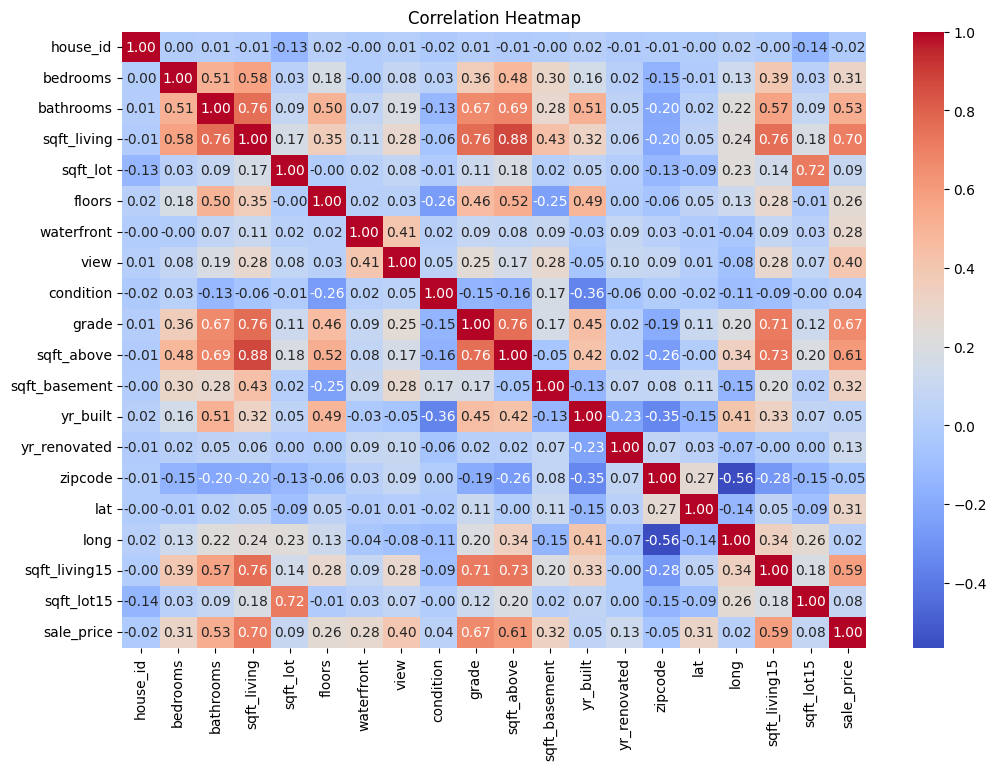

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your local CSV with pandas
data = pd.read_csv('.data/king_county_houses_joined.csv')

# Compute correlation matrix (numeric columns only)
correlation_matrix = data.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()

In [20]:
# mark if a ZIP is a golf ZIP
zip_avg['is_golf_zip'] = zip_avg['zipcode'].isin(golf_zipcodes)

In [21]:
golf_vs_non = (
    zip_avg.groupby('is_golf_zip')['price_per_sqft']
           .mean()
           .reset_index()
           .replace({True: "Golf ZIPs", False: "Non-Golf ZIPs"})
)

print(golf_vs_non)

     is_golf_zip  price_per_sqft
0  Non-Golf ZIPs         273.221
1      Golf ZIPs         256.734


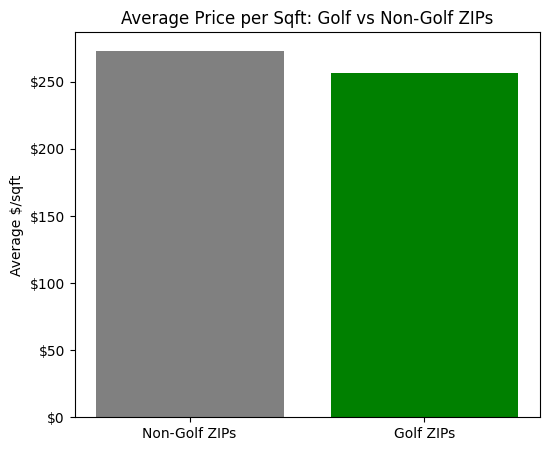

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(6,5))
plt.bar(golf_vs_non['is_golf_zip'], golf_vs_non['price_per_sqft'],
        color=['gray', 'green'])

plt.title("Average Price per Sqft: Golf vs Non-Golf ZIPs")
plt.ylabel("Average $/sqft")
plt.xticks(rotation=0)

# format y-axis with $ and commas
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.show()

In [23]:
#  Make sure types are right
df['zipcode'] = df['zipcode'].astype(str).str.strip()
df['sale_price'] = pd.to_numeric(df['sale_price'], errors='coerce')

# Optional: drop rows without a price
df = df.dropna(subset=['sale_price'])

# Golf ZIP list (King County, WA)
golf_zipcodes = [
    "98005", "98008", "98022", "98024", "98028", "98032", "98038", "98042",
    "98045", "98052", "98053", "98058", "98059", "98065", "98074", "98092",
    "98103", "98108", "98112", "98115", "98119", "98125", "98126", "98168",
    "98177"
]

# Mark each property as Golf / Non-Golf
df['is_golf_zip'] = df['zipcode'].isin(golf_zipcodes)

# Aggregate: average sale price + median + count
summary = (
    df.groupby('is_golf_zip')['sale_price']
      .agg(avg_sale_price='mean', median_sale_price='median', n_properties='count')
      .reset_index()
      .replace({True: 'Golf ZIPs', False: 'Non-Golf ZIPs'})
 
)

# Show 
print(summary)

     is_golf_zip  avg_sale_price  median_sale_price  n_properties
0  Non-Golf ZIPs      552128.081         450000.000         12958
1      Golf ZIPs      522549.997         450000.000          8639


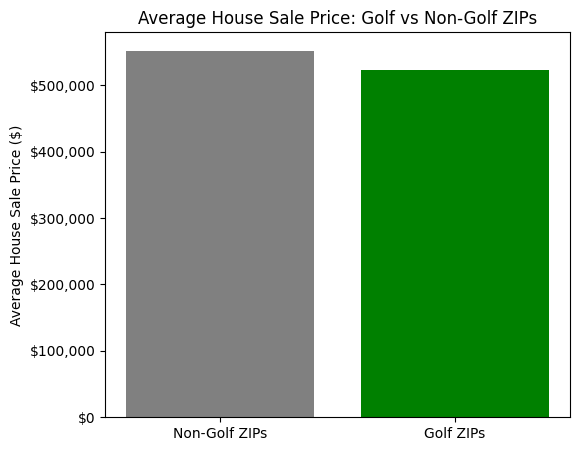

In [24]:
#plotting Bar Chart of Average Sale Price
plt.figure(figsize=(6,5))
plt.bar(summary['is_golf_zip'], summary['avg_sale_price'], color=['gray', 'green'])

plt.title("Average House Sale Price: Golf vs Non-Golf ZIPs")
plt.ylabel("Average House Sale Price ($)")
plt.xticks(rotation=0)

# format y-axis with commas
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.show()

**Interpretation of results in correlation to Hypothesis 1:**

Golf ZIPs average price per sqft ≤ non Golf ZIPs average price per sqft
(256.73 dollar/sqft < 273.22 dollar/sqft)

These results were unexpected and doesnt support the Hypothesis(1). (at least for this dataset and time period). This could indicate that there are other factors which influence the average price per sqft. Maybe the basement on waterfront is the dominant factor for average sell prices in this region. 

----------------------

# Hypothesis 2:

“The higher the average neighbor lot size, the more likely the property itself has a large estate-style lot.”

 - This hypothesis is essentially about correlation between sqft_lot and sqft_lot15.

 - A positive correlation (closer to +1) supports H2.
 - If correlation is weak (close to 0) or negative, H2 is not supported.

In [25]:
# Check the correlation
corr = df[['sqft_lot', 'sqft_lot15']].corr(method='pearson')
print(corr)

            sqft_lot  sqft_lot15
sqft_lot       1.000       0.718
sqft_lot15     0.718       1.000


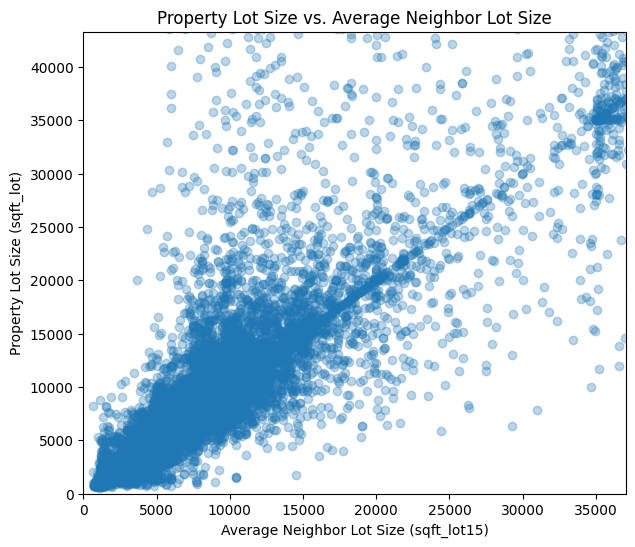

In [26]:
plt.figure(figsize=(7,6))
plt.scatter(df['sqft_lot15'], df['sqft_lot'], alpha=0.3)

plt.title("Property Lot Size vs. Average Neighbor Lot Size")
plt.xlabel("Average Neighbor Lot Size (sqft_lot15)")
plt.ylabel("Property Lot Size (sqft_lot)")
plt.xlim(0, df['sqft_lot15'].quantile(0.95))  # trim extreme outliers
plt.ylim(0, df['sqft_lot'].quantile(0.95))

plt.show()

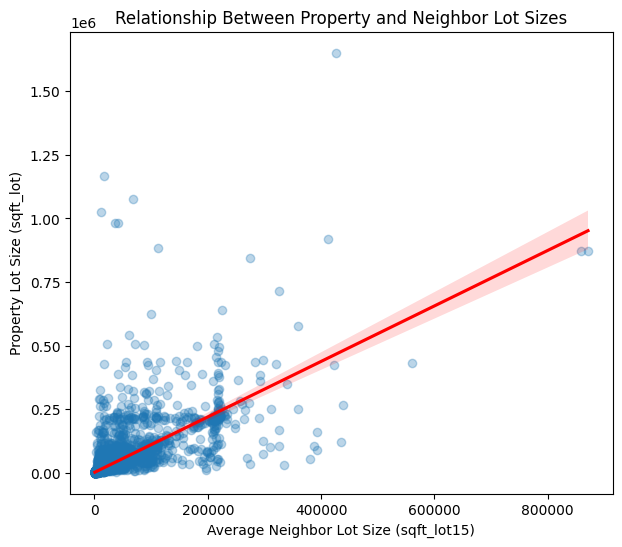

In [27]:
plt.figure(figsize=(7,6))
sns.regplot(x='sqft_lot15', y='sqft_lot', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Relationship Between Property and Neighbor Lot Sizes")
plt.xlabel("Average Neighbor Lot Size (sqft_lot15)")
plt.ylabel("Property Lot Size (sqft_lot)")
plt.show()

**Interpretation of results in correlation to Hypothesis 2:**

- Scatter/hexbin plots should show an upward trend (points clustering along a diagonal line).
- this indicates a positive correlation, which means: Properties in areas with larger average neighbor lots also tend to have larger individual lots.
→ This supports Hypothesis 2

---------------

# Hypothesis 3

"If a a property is historic, then it is more likely to be situated on larger lots."

First I need to check how my customer defines historic: before 1940 (older than ~75 years).

In [28]:
df['is_historic'] = df['yr_built'] < 1950

In [29]:
lot_summary = (
    df.groupby('is_historic')['sqft_lot']
      .agg(avg_lot_size='mean', median_lot_size='median', n_properties='count')
      .reset_index()
      .replace({True: 'Historic (<1950)', False: 'Non-Historic (>=1950)'})
)

print(lot_summary)

             is_historic  avg_lot_size  median_lot_size  n_properties
0  Non-Historic (>=1950)     16549.431         8189.000         16662
1       Historic (<1950)     10203.712         5635.000          4935


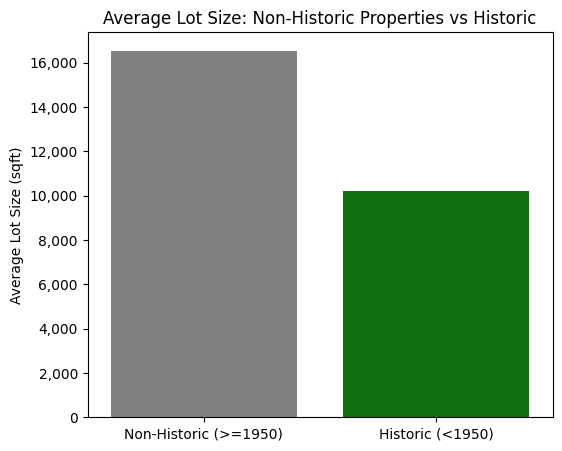

In [30]:
plt.figure(figsize=(6,5))
sns.barplot(x='is_historic', y='sqft_lot', data=df,
            palette=['gray', 'green'],  # shows avg + error bars
            errorbar=None)

plt.title("Average Lot Size: Non-Historic Properties vs Historic")
plt.xlabel("")
plt.ylabel("Average Lot Size (sqft)")
plt.xticks([0,1], ["Non-Historic (>=1950)" , "Historic (<1950)"])

# format y-axis with commas
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

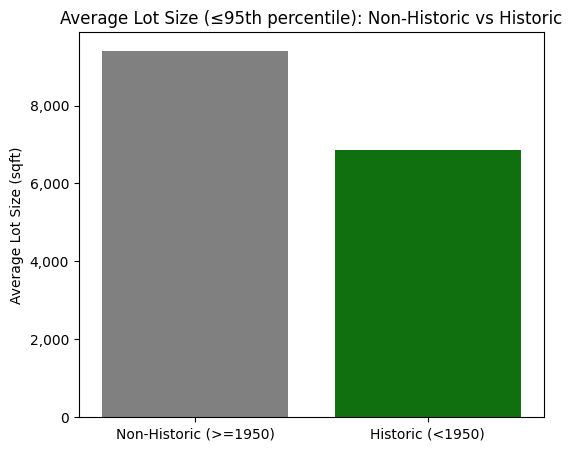

In [31]:
# calculate cutoff
cutoff = df['sqft_lot'].quantile(0.95)

# filter dataset
df_trimmed = df[df['sqft_lot'] <= cutoff]

plt.figure(figsize=(6,5))
sns.barplot(x='is_historic', y='sqft_lot', data=df_trimmed,
            palette=['gray', 'green'], errorbar=None)

plt.title("Average Lot Size (≤95th percentile): Non-Historic vs Historic")
plt.xlabel("")
plt.ylabel("Average Lot Size (sqft)")
plt.xticks([0,1], ["Non-Historic (>=1950)" , "Historic (<1950)"])

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

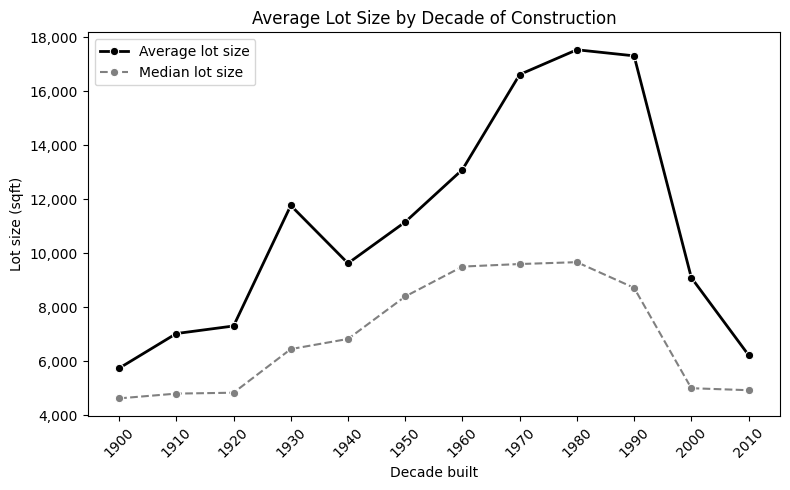

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Prep: keep valid years & lots ---
df_tmp = df.copy()
df_tmp = df_tmp[(df_tmp['yr_built'].notna()) & (df_tmp['yr_built'] > 1800)]
df_tmp = df_tmp[df_tmp['sqft_lot'] > 0]

# Optional: trim extreme lots so trend isn’t dominated by outliers (comment out to disable)
cutoff = df_tmp['sqft_lot'].quantile(0.99)
df_tmp = df_tmp[df_tmp['sqft_lot'] <= cutoff]

# --- Build decade column ---
df_tmp['decade'] = (df_tmp['yr_built'] // 10 * 10).astype(int)

# --- Aggregate by decade ---
trend = (
    df_tmp.groupby('decade')['sqft_lot']
          .agg(avg_lot='mean', med_lot='median', n='count')
          .reset_index()
          .sort_values('decade')
)

# --- Plot: average lot size by decade ---
plt.figure(figsize=(8,5))
sns.lineplot(data=trend, x='decade', y='avg_lot', marker='o', linewidth=2, color='black', label='Average lot size')
sns.lineplot(data=trend, x='decade', y='med_lot', marker='o', linewidth=1.5, linestyle='--', color='gray', label='Median lot size')

plt.title("Average Lot Size by Decade of Construction")
plt.xlabel("Decade built")
plt.ylabel("Lot size (sqft)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(trend['decade'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


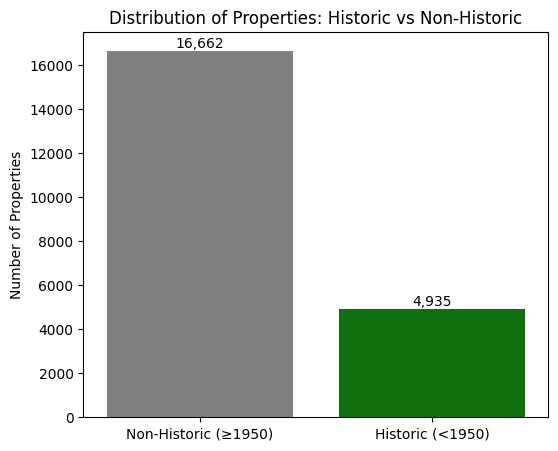

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a new column for historic vs non-historic
df['property_age'] = df['yr_built'].apply(lambda x: "Historic (<1950)" if x < 1950 else "Non-Historic (≥1950)")

# Count properties by group
counts = df['property_age'].value_counts().reset_index()
counts.columns = ['Property Type', 'Count']

# Plot
plt.figure(figsize=(6,5))
sns.barplot(data=counts, x='Property Type', y='Count', palette=['gray','green'])

plt.title("Distribution of Properties: Historic vs Non-Historic")
plt.ylabel("Number of Properties")
plt.xlabel("")
plt.xticks(rotation=0)

# Add labels on top of bars
for i, row in counts.iterrows():
    plt.text(i, row['Count'], f"{row['Count']:,}", ha='center', va='bottom')

plt.show()

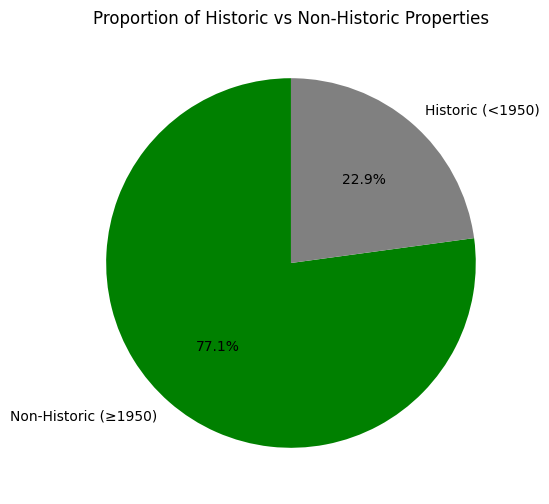

In [34]:
import matplotlib.pyplot as plt

counts = df['property_age'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['green','gray']
)
plt.title("Proportion of Historic vs Non-Historic Properties")
plt.show()

Interpretation H3: 
- This pattern holds across both central tendency measures, so it’s not just due to outliers.
- The sample size is also much larger for non-historic properties, but the difference in lot size is big enough that it’s unlikely to be explained by sample imbalance alone.

**Conclusion**
--> The data shows that historic properties tend to be on smaller lots, not larger ones.
Therefore, H3 is **not** supported

Being a historic property (<1950) does not make it more likely to have a large “estate-style” lot. In fact, newer homes tend to sit on bigger lots on average.

____________________

# Business question:

Which properties best meet the client’s requirements for a large, historic estate with 4+ bathrooms
(or a smaller nearby alternative), featuring luxury amenities (tennis court and pool), proximity to golf, and explicitly 
excluding waterfront locations?

What is already known?

|Proberties build in: | avg_lot_size  | median_lot_size  | n_properties |
| ----------- | ----------- | ------------- | ------------ |
| Non-Historic (>=1950) | 16549.431 |       8189.000    |        16662 |
| Historic (<1950)   |         10203.712      |  5635.000     |        4935 |

Properties located near golf courses:

| Total properties in dataset: | 21597 |
| ------------- | ------------ |
| Properties in golf-course ZIPs: |  **8639** |





Defining the minimum lot size 

**Tennis Court**
- Standard doubles court: about 60 ft × 120 ft = 7,200 sqft
- Recommended buffer around court: +10–12 ft each side for fencing & runoff --> **round about 8,500 sqft** 

**Pool**
- Typical residential pool: 15 × 30 ft (~450 sq ft water area)
- With deck & safety clearance: **~1,500sqft**

**Other Space**
- house footbrint & circulation: **~ 5,000 sqft**
- Driveway, yard & setback buffers: **~ 5,000 sqft**

Minimum lot size: about **20,000 sqft** for the **Dream-Property** 🏡

For comfortable layout without things feeling crammed bigger lots are also in scope

In [35]:
# Golf ZIP list (from earlier)
golf_zipcodes = [
    "98005","98008","98022","98024","98028","98032","98038","98042",
    "98045","98052","98053","98058","98059","98065","98074","98092",
    "98103","98108","98112","98115","98119","98125","98126","98168","98177"]

# Historic + estate threshold
estate_threshold = 20000  

# Candidate properties
candidates = df[
    (df['yr_built'] < 1950) &
    (df['bathrooms'] >= 4) &
    (df['waterfront'] == 0) &
    (df['zipcode'].isin(golf_zipcodes)) &
    (df['sqft_lot'] >= estate_threshold)]

# Separate into estate-style vs smaller alternatives
large_estates = candidates[candidates['sqft_lot'] >= estate_threshold]

print("Large estates that match criteria:", large_estates.shape[0])


# Show top matches (sorted by price or size)
large_estates.sort_values(by='sale_price', ascending=False).head()

Large estates that match criteria: 3


,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,lat,long,sqft_living15,sqft_lot15,sale_date,sale_price,price_per_sqft,is_golf_zip,is_historic,property_age
18314,5317100750,4.000,4.750,4575.000,24085.000,2.500,0.000,2.000,5,10,...,47.626,-122.284,3900.000,9687.000,2014-07-11,2920000.000,638.251,True,True,Historic (<1950)
14172,1333300145,3.000,4.000,4200.000,30120.000,2.000,0.000,2.000,4,11,...,47.638,-122.311,2760.000,12200.000,2015-03-04,2230000.000,530.952,True,True,Historic (<1950)
15152,3304700130,4.000,4.000,3860.000,67953.000,2.000,0.000,2.000,4,12,...,47.747,-122.378,4410.000,128066.000,2015-01-28,1760000.000,455.959,True,True,Historic (<1950)


In [36]:
# plot map of candidate properties on a scattermap

import plotly.graph_objects as go

    
fig = go.Figure(go.Scattermap(
        lat=['47.626','47.638','47.747',],
        lon=['-122.284','-122.311','-122.378'],
        mode='markers',
        marker=go.scattermap.Marker(
            size=10
        ),
        text=["House 1: 2,920,000 $","House 2: 2,230,000 $","House 3: 1,760,000 $",],
    ))
    

fig.update_layout(
    autosize=True,
    hovermode='closest',
    map=dict(
        bearing=2,
        center=dict(
            lat=47.747,
            lon=-122.384
        ),
        pitch=5,
        zoom=8
    ),
)

fig.show()



In [37]:
# Add golf clubs in red

import plotly.graph_objects as go 

golf_clubs = [
    ("Golf Club Seatlle", 47.73777313577974, -122.36065184866378),
    ("Broadmoor Golf Club", 47.64060139508901, -122.29137342367203),]
    
fig = go.Figure(go.Scattermap(
        lat=['47.626','47.638','47.747',],
        lon=['-122.284','-122.311','-122.378'],
        mode='markers',
        marker=go.scattermap.Marker(
            size=10
        ),
        text=["House 1: 2,920,000 $","House 2: 2,230,000 $","House 3: 1,760,000 $",],
        name="Properties"
    ))

#  Add golf clubs in red
fig.add_trace(go.Scattermap(
        lat=[str(club[1]) for club in golf_clubs],
        lon=[str(club[2]) for club in golf_clubs],
        mode='markers',
        marker=go.scattermap.Marker(
            size=12,
            color="red"
        ),
        text=[club[0] for club in golf_clubs],
        name="Golf Clubs"
    ))

fig.update_layout(
    autosize=True,
    hovermode='closest',
    map=dict(
        bearing=0,
        center=dict(
            lat=47.747,
            lon=-122.384
        ),
        pitch=5,
        zoom=8.5,
        
    ),
)

fig.show()

In [38]:
import plotly.graph_objects as go 

golf_clubs = [
    ("Golf Club Seattle", 47.73777313577974, -122.36065184866378),
    ("Broadmoor Golf Club", 47.64060139508901, -122.29137342367203),
]

# Base map with properties
fig = go.Figure(go.Scattermapbox(
    lat=['47.626','47.638','47.747'],
    lon=['-122.284','-122.311','-122.378'],
    mode='markers',
    marker=dict(size=10, color="blue"),
    text=["House 1: 2,920,000 $", "House 2: 2,230,000 $", "House 3: 1,760,000 $"],
    name="Dream House Locations"
))

# Add golf clubs in red
fig.add_trace(go.Scattermapbox(
    lat=[club[1] for club in golf_clubs],
    lon=[club[2] for club in golf_clubs],
    mode='markers',
    marker=dict(size=12, color="red"),
    text=[club[0] for club in golf_clubs],
    name="Golf Clubs"
))

# Layout with legend integrated into the map
fig.update_layout(
    autosize=True,
    hovermode='closest',
    mapbox=dict(
        style="carto-positron",  # visible basemap
        bearing=0,
        center=dict(lat=47.7, lon=-122.35),
        pitch=5,
        zoom=9,
    ),
    height=800,
    width=800,
    legend=dict(
        title="",
        bgcolor="rgba(255,255,255,0.7)",  # semi-transparent background
        orientation="h",                  # horizontal layout
        yanchor="bottom", y=0.02,         # push slightly above bottom
        xanchor="left", x=0.02            # push slightly right from left edge
    )
)

fig.show()


In [39]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="long",
    zoom=9,
    height=800,
    width=800,
    opacity=0.4,
    mapbox_style="carto-positron"
)

# make dots smaller (default is ~10)
fig.update_traces(marker=dict(size=5))

fig.show()

In [40]:
import plotly.express as px

# Base scatter with properties (blue)
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="long",
    zoom=9,
    height=800,
    width=800,
    opacity=0.4,
    mapbox_style="carto-positron",
    color_discrete_sequence=["blue"]  # force properties to be blue
)

# Make property dots smaller & add legend label
fig.update_traces(marker=dict(size=5), name="Properties", showlegend=True)

# Add golf ZIP centroids (red)
golf_centroids = (
    df[df['zipcode'].isin(golf_zipcodes)]
    .groupby('zipcode')[['lat', 'long']]
    .mean()
    .reset_index()
)

fig.add_scattermapbox(
    lat=golf_centroids['lat'],
    lon=golf_centroids['long'],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=golf_centroids['zipcode'],
    textposition="top center",
    name="Golf ZIPs",
    showlegend=True
)

# Add title + legend layout
fig.update_layout(
    title="Overview Properties & Golfcourse Zip Codes",
    legend=dict(title="", orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)

fig.show()


In [41]:
import plotly.express as px

# Mark golf vs non-golf properties
df['is_golf_zip'] = df['zipcode'].astype(str).isin(golf_zipcodes)
df['property_group'] = df['is_golf_zip'].replace({True: "Golf ZIP properties", False: "Other properties"})

# Base scatter with grouped coloring
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="long",
    color="property_group",
    color_discrete_map={
        "Golf ZIP properties": "green",
        "Other properties": "lightgrey"
    },
    zoom=9,
    height=800,
    width=800,
    opacity=0.5,
    mapbox_style="carto-positron"
)

# Adjust marker size
fig.update_traces(marker=dict(size=5))

# Add golf ZIP centroids (red with labels)
golf_centroids = (
    df[df['zipcode'].astype(str).isin(golf_zipcodes)]
    .groupby('zipcode')[['lat', 'long']]
    .mean()
    .reset_index()
)

fig.add_scattermapbox(
    lat=golf_centroids['lat'],
    lon=golf_centroids['long'],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=golf_centroids['zipcode'],
    textposition="top center",
    name="Golf ZIP centroids",
    showlegend=True
)

# Add title + legend layout
fig.update_layout(
    title="Overview Properties: Golf ZIPs vs Others",
    legend=dict(title="", orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)

fig.show()


In [42]:
import pandas as pd
import plotly.express as px

# --- Prep ---
df['zipcode'] = df['zipcode'].astype(str)

# If not already defined:
golf_zipcodes = [
    "98005","98008","98022","98024","98028","98032","98038","98042",
    "98045","98052","98053","98058","98059","98065","98074","98092",
    "98103","98108","98112","98115","98119","98125","98126","98168","98177"
]
# Large historic estates (green)
houses = df[
    (df['sqft_lot'] > 20000) &
    (df['yr_built'] < 1950) &
    (df['bathrooms'] > 2)
].copy()

# Guest houses (blue): lot 5k–10k, >2 baths, and in golf ZIPs
guest_houses = df[
    df['zipcode'].isin(golf_zipcodes) &
    df['sqft_lot'].between(10000, 20000) &
    (df['bathrooms'] > 2)
].copy()

# Golf ZIP centroids (red)
golf_centroids = (
    df[df['zipcode'].isin(golf_zipcodes)]
    .groupby('zipcode')[['lat', 'long']]
    .mean()
    .reset_index()
)

# Base figure with historic estates (green)
fig = px.scatter_mapbox(
    houses,
    lat="lat",
    lon="long",
    hover_name="id" if "id" in houses.columns else None,
    hover_data=[c for c in ["sale_price", "sqft_lot", "bathrooms", "yr_built", "zipcode"] if c in houses.columns],
    color_discrete_sequence=["green"],
    zoom=9,
    height=800,
    width=800,
    mapbox_style="carto-positron",
)
fig.update_traces(
    name="Historic estates (>20k sqft & >2 baths)",
    showlegend=True,
    marker=dict(size=9)
)

# Add guest houses (blue) 
guest_fig = px.scatter_mapbox(
    guest_houses,
    lat="lat",
    lon="long",
    hover_name="id" if "id" in guest_houses.columns else None,
    hover_data=[c for c in ["sale_price", "sqft_lot", "bathrooms", "yr_built", "zipcode"] if c in guest_houses.columns],
    color_discrete_sequence=["blue"],
    mapbox_style="carto-positron",
)
guest_trace = guest_fig.data[0]
guest_trace.name = "Guest houses (10k–20k sqft, >2 baths)"
guest_trace.marker.update(size=9)
guest_trace.showlegend = True
fig.add_trace(guest_trace)

# Add golf ZIP centroids (red) with labels ---
fig.add_scattermapbox(
    lat=golf_centroids['lat'],
    lon=golf_centroids['long'],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=golf_centroids['zipcode'],
    textposition="top center",
    name="Golf ZIPs",
    showlegend=True,
)
#  Layout with title + legend 

fig.update_layout(
    title="Alternative Historic Estates with potential Guest Houses in range of Golf ZIPs",
    legend=dict(title="", orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)

fig.show()

In [45]:
import pandas as pd
import plotly.express as px

# --- Prep ---
df['zipcode'] = df['zipcode'].astype(str)

# If not already defined:
golf_zipcodes = [
    "98005","98008","98022","98024","98028","98032","98038","98042",
    "98045","98052","98053","98058","98059","98065","98074","98092",
    "98103","98108","98112","98115","98119","98125","98126","98168","98177"
]

# Large historic estates (green) - exclude waterfront
houses = df[
    (df['sqft_lot'] > 20000) &
    (df['yr_built'] < 1950) &
    (df['house_id'] ) &
    (df['zipcode'] ) &
    (df['bathrooms'] > 2) &
    (df['waterfront'] == 0)   # exclude waterfront
].copy()

# Guest houses (blue): lot 10k–20k, >2 baths, in golf ZIPs - exclude waterfront
guest_houses = df[
    df['zipcode'].isin(golf_zipcodes) &
    df['sqft_lot'].between(10000, 20000) &
    (df['bathrooms'] > 2) &
    (df['yr_built'] < 1950) &
    (df['house_id'] ) &
    (df['zipcode'] ) &
    (df['waterfront'] == 0)   # exclude waterfront
].copy()

# Golf ZIP centroids (red)
golf_centroids = (
    df[df['zipcode'].isin(golf_zipcodes)]
    .groupby('zipcode')[['lat', 'long']]
    .mean()
    .reset_index()
)

# Base figure with historic estates (green)
fig = px.scatter_mapbox(
    houses,
    lat="lat",
    lon="long",
    hover_name="id" if "id" in houses.columns else None,
    hover_data=[c for c in ["house_id", "sale_price", "sqft_lot", "bathrooms", "yr_built", "zipcode"] if c in houses.columns],
    color_discrete_sequence=["green"],
    zoom=9,
    height=800,
    width=800,
    mapbox_style="carto-positron",
)
fig.update_traces(
    name="Historic estates (>20k sqft & >2 baths, no waterfront)",
    showlegend=True,
    marker=dict(size=9)
)

# Add guest houses (blue) 
guest_fig = px.scatter_mapbox(
    guest_houses,
    lat="lat",
    lon="long",
    hover_name="id" if "id" in guest_houses.columns else None,
    hover_data=[c for c in ["sale_price", "sqft_lot", "bathrooms", "yr_built", "zipcode" , "house_id"] if c in guest_houses.columns],
    color_discrete_sequence=["blue"],
    mapbox_style="carto-positron",
)
guest_trace = guest_fig.data[0]
guest_trace.name = "Guest houses (10k–20k sqft, >2 baths, no waterfront)"
guest_trace.marker.update(size=9)
guest_trace.showlegend = True
fig.add_trace(guest_trace)

# Add golf ZIP centroids (red) with labels
fig.add_scattermapbox(
    lat=golf_centroids['lat'],
    lon=golf_centroids['long'],
    mode="markers+text",
    marker=dict(size=12, color="red"),
    text=golf_centroids['zipcode'],
    textposition="top center",
    name="Golf ZIPs",
    showlegend=True,
)

# Layout with title + legend 
fig.update_layout(
    title="Alternative Historic Estates with Guest Houses in Golf ZIPs (Excluding Waterfronts)",
    legend=dict(title="", orientation="h", yanchor="bottom", y=0.01, xanchor="left", x=0.01)
)

fig.show()
